In [1]:
import Pkg
Pkg.activate("./")
Pkg.instantiate()

  Activating project at `~/Desktop/git_projects/Causal sets/CausalSetZoology/analysis`


In [37]:
function fig_path(fig_name::String)
        path = "/Users/fabianwagner/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        #"/Users/fabian/Dropbox/Fabian/Research/Shared Folders/CausalSetZoology/figs/"
        return "$(path)$(fig_name)"
end

using Revise
includet("analysis.jl")

In [3]:
import Colors
colors = [
                Colors.colorant"#F1C21B",  # IBM Yellow
                Colors.colorant"#D12771",  # IBM Magenta
                Colors.colorant"#009D9A",  # IBM Teal
                Colors.colorant"#0F62FE",  # IBM Blue
                Colors.colorant"#6F6F6F",  # IBM Gray
                Colors.colorant"#FA4D56",  # IBM Red
                Colors.colorant"#24A148",  # IBM Green
        ]

In [ ]:
candidates = [
    "/Volumes/Causal Set Silo/causal_sets/analysis/",
    "/Volumes/Causal Set Silochen/causal_sets/analysis/",
]

root_path = let p = findfirst(isdir, candidates)
    p === nothing && error("No analysis path found")
    candidates[p]
end

function data_paths(file_names::Vector{String})::Vector{String}
    return [joinpath(root_path, file_name) for file_name in file_names]
end

In [ ]:
import JLD2
using CairoMakie
using Distributions

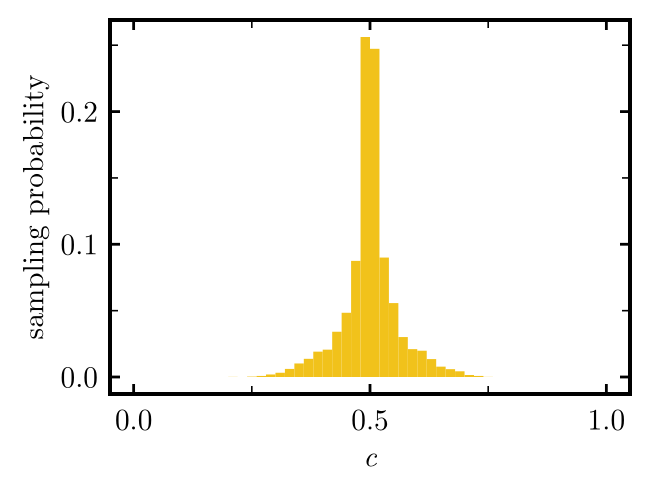

CairoMakie.Screen{PDF}


In [36]:
figsize = apply_paper_theme!()

xs = 0:0.001:1
ys = pdf.(distribution, xs)


data = JLD2.load("../scripts/connectivity_dist.jld2")
edges = data["edges"]
p = data["probabilities"]

centers = (edges[1:end-1] .+ edges[2:end]) ./ 2
widths = diff(edges)

f = Figure(size = figsize)
ax = Axis(f[1, 1], xlabel=L"c", ylabel="sampling probability")


barplot!(ax, centers, p; width=widths, gap=0, color = colors[1])

display(f)

save(fig_path("sketches/connectivity_man_hist.pdf"), f)


In [46]:
path = data_paths(["random_2048_10000/statistics.jld2"])[1]

"/Volumes/Causal Set Silo/causal_sets/analysis/random_2048_10000/statistics.jld2"

In [64]:
connectivity = Float64[]

JLD2.jldopen(path) do f
    batchsize = f["meta"]["batchsize"]
    nbatches = f["meta"]["nbatches"]
    for batch in 1:nbatches
        batch = f["batches/$batch"]
        for element in batch
            append!(connectivity, element.connectivity)
        end
    end
end

In [66]:
import StatsBase

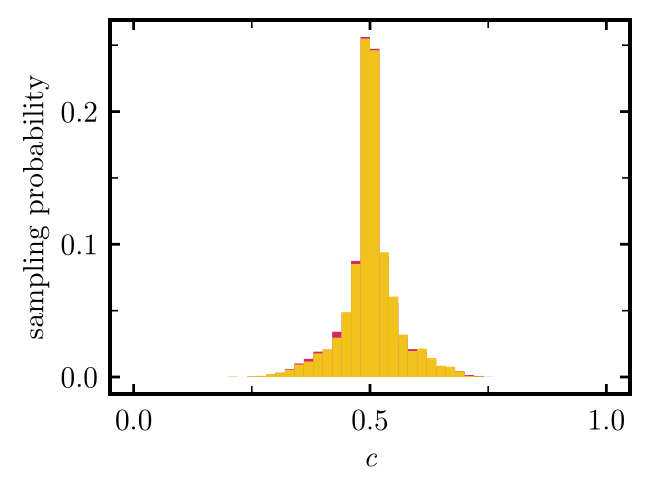

CairoMakie.Screen{IMAGE}


In [75]:
distdata = JLD2.load("../scripts/connectivity_dist.jld2")
edges = distdata["edges"]

h = StatsBase.fit(StatsBase.Histogram, connectivity, edges)
counts = h.weights
p_res = counts ./ sum(counts)
centers_res = (edges[1:end-1] .+ edges[2:end]) ./ 2

edges = data["edges"]
p = data["probabilities"]

centers = (edges[1:end-1] .+ edges[2:end]) ./ 2
widths = diff(edges)


f = Figure(size = figsize)
ax = Axis(f[1, 1], xlabel=L"c", ylabel="sampling probability")

barplot!(ax, centers, p; width=widths, gap=0, color = colors[2])
barplot!(ax, centers_res, p_res; width=widths, gap=0, color = colors[1])

display(f)

# Myrheim-Myers dimension

In [78]:
import CausalSets

In [99]:
path_data = data_paths(["random_2048_10000/dataset.jld2"])[1]
path_data_man = data_paths(["manifoldlike_simply_connected_2048_10000/dataset.jld2"])[1]

"/Volumes/Causal Set Silo/causal_sets/analysis/manifoldlike_simply_connected_2048_10000/dataset.jld2"

In [106]:
myrheim_meyer = Float64[]

JLD2.jldopen(path_data) do f
    keys(f["batches/1"])
    batchsize = f["meta/batchsize"]
    nbatches = f["meta/nbatches"]
    for batch in 1:nbatches
        csets = f["batches/$batch/csets"]
        for cset in csets
            append!(myrheim_meyer, CausalSets.estimate_relation_dimension(cset))
        end
    end
end

In [104]:
myrheim_meyer_man = Float64[]

JLD2.jldopen(path_data_man) do f
    keys(f["batches/1"])
    batchsize = f["meta/batchsize"]
    nbatches = f["meta/nbatches"]
    for batch in 1:nbatches
        csets = f["batches/$batch/csets"]
        for cset in csets
            append!(myrheim_meyer_man, CausalSets.estimate_relation_dimension(cset))
        end
    end
end

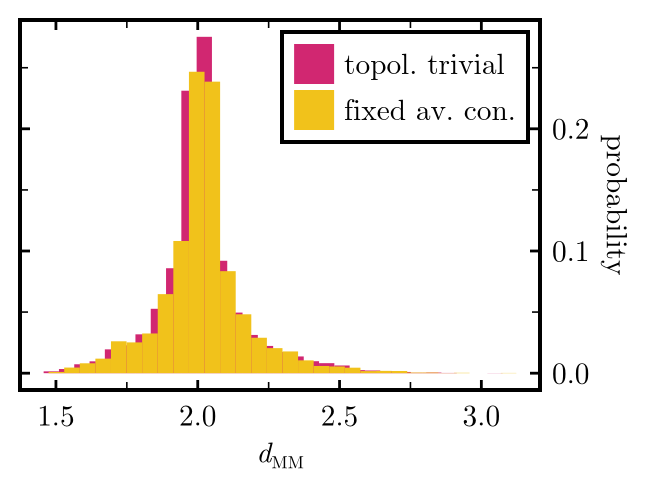

CairoMakie.Screen{PDF}


In [120]:
figsize = apply_paper_theme!()
f = Figure(size = figsize)
ax = Axis(f[1,1]; 
    xlabel = L"d_{\mathrm{MM}}", 
    ylabel = "probability",
    yaxisposition = :right,
    ylabelrotation = -pi/2,)

hist!(myrheim_meyer_man; bins=30, normalization=:probability, color = colors[2],label = "topol. trivial")
hist!(myrheim_meyer; bins=30, normalization=:probability, color = colors[1], label = "fixed av. con.")

axislegend(ax, position=:rt)
display(f)

save(fig_path("graph_observables/myrheim_meyer_dim_random_man.pdf"),f)

In [103]:
myrheim_meyer_man

Float64[]

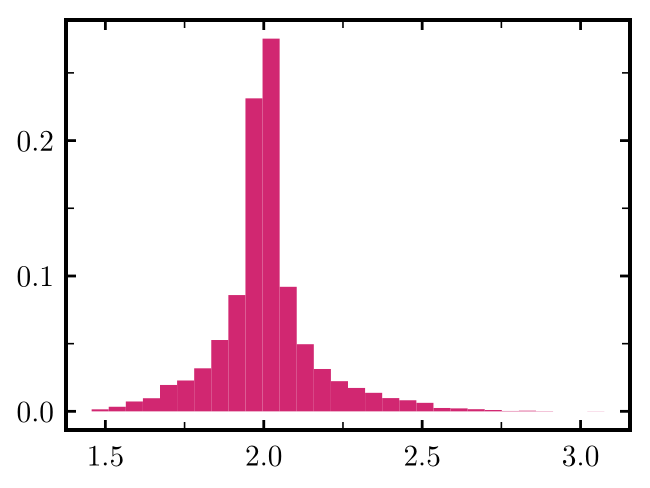

In [105]:
figsize = apply_paper_theme!()
f = Figure(size = figsize)
ax = Axis(f[1,1])

hist!(myrheim_meyer_man; bins=30, normalization=:probability, color = colors[2])
f